# GRN Accuracy Evaluations with scMultiSim

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import numpy as np
import pandas as pd

In [3]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
sys.path.append("/home/chenxufeng/WorkSpace/scMagnify/src/")
from grn_tools import batch_evaluate_scMultiSim, METHOD_PALETTE_SCMULTISIM, plot_horizontal_boxplot, show_color

/picb/lihonglab/chenxufeng/miniconda3/envs/scm_test/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/picb/lihonglab/chenxufeng/miniconda3/envs/scm_test/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/picb/lihonglab/chenxufeng/miniconda3/envs/scm_test/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/picb/lihonglab/chenxufeng/miniconda3/envs/scm_test/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/picb/lihonglab/chenxufeng/miniconda3/

## Configurations

In [5]:
%matplotlib inline

plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.family"] = "Arial"
plt.rcParams["image.cmap"] = "Spectral_r"

# For saving vector graphics
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams["text.usetex"] = False

In [6]:
fig_dir = "../figures/Fig2/" 
if not os.path.exists(fig_dir):
    os.makedirs(fig_dir)
data_dir = "../data/Fig2/"
if not os.path.exists(data_dir):
    os.makedirs(data_dir)

## Calculate the Metrics

In [7]:
metrics_df = batch_evaluate_scMultiSim(
    algo_list = ["CellOracle", "scMagnify"]
)

Output()

In [8]:
metrics_df.head()

,Algorithm,Dataset,Nums_TF,Nums_Target,Precsions,Recalls,AUPR,AUPR Ratio1,AUPR Ratio2,FPRs,TPRs,AUROC,Confusion Matrix,Precision,Recall,F1 Score(topk),F0.1 Score(topk)
0,CellOracle,grn1139_tree1_1000_cells1139_genes_sigma0.1_5,6,1130,"[0.21009389671361503, 0.7344188658057271, 0.73...","[1.0, 0.9134078212290503, 0.9127094972067039, ...",0.771811,3.673649,3.725689,"[0.0, 0.0, 0.0, 0.00018573551263001485, 0.0001...","[0.0, 0.0006983240223463687, 0.005586592178770...",0.924468,"[[4911, 473], [124, 1308]]",0.734419,0.913408,0.814192,0.735847
1,CellOracle,grn1139_noise_tree1_1000_cells1139_genes_sigma...,6,1130,"[0.21009389671361503, 0.7475504322766571, 0.74...","[1.0, 0.9057262569832403, 0.9050279329608939, ...",0.759539,3.615237,3.572026,"[0.0, 0.0, 0.0, 0.00018573551263001485, 0.0001...","[0.0, 0.0006983240223463687, 0.018854748603351...",0.918928,"[[4946, 438], [135, 1297]]",0.747550,0.905726,0.819072,0.748845
2,CellOracle,grn1139_tree1_1000_cells1139_genes_sigma0.1_8,6,1130,"[0.21009389671361503, 0.7422272470322216, 0.74...","[1.0, 0.9168994413407822, 0.9162011173184358, ...",0.734898,3.497950,3.562721,"[0.0, 0.00018573551263001485, 0.00037147102526...","[0.0, 0.0, 0.0, 0.0006983240223463687, 0.00069...",0.924330,"[[4928, 456], [119, 1313]]",0.742227,0.916899,0.820369,0.743630
3,CellOracle,grn1139_tree1_1000_cells1139_genes_sigma0.1_7,6,1130,"[0.21009389671361503, 0.7429245283018868, 0.74...","[1.0, 0.8798882681564246, 0.8791899441340782, ...",0.747375,3.557336,3.577795,"[0.0, 0.0, 0.0, 0.00018573551263001485, 0.0001...","[0.0, 0.0006983240223463687, 0.017458100558659...",0.908072,"[[4948, 436], [172, 1260]]",0.742925,0.879888,0.805627,0.744071
4,CellOracle,grn100_noise_tree1_1000_cells110_genes_sigma0....,6,94,"[0.21666666666666667, 0.21885521885521886, 0.2...","[1.0, 1.0, 0.9923076923076923, 0.9923076923076...",0.398909,1.841120,1.619517,"[0.0, 0.0, 0.006382978723404255, 0.00638297872...","[0.0, 0.007692307692307693, 0.0076923076923076...",0.702987,"[[6, 464], [0, 130]]",0.218855,1.000000,0.359116,0.220561


In [9]:
metrics_df.to_csv(os.path.join(data_dir, "Fig2-scMultiSim_raw_metrics_df.csv"), index=False)

In [9]:
metrics_df[	["Algorithm", "Dataset", "AUPR", "AUROC", "F1 Score(topk)"]]

,Algorithm,Dataset,AUPR,AUROC,F1 Score(topk)
0,CellOracle,grn1139_tree1_1000_cells1139_genes_sigma0.1_5,0.771811,0.924468,0.814192
1,CellOracle,grn1139_noise_tree1_1000_cells1139_genes_sigma...,0.759539,0.918928,0.819072
2,CellOracle,grn1139_tree1_1000_cells1139_genes_sigma0.1_8,0.734898,0.924330,0.820369
3,CellOracle,grn1139_tree1_1000_cells1139_genes_sigma0.1_7,0.747375,0.908072,0.805627
4,CellOracle,grn100_noise_tree1_1000_cells110_genes_sigma0....,0.398909,0.702987,0.359116
...,...,...,...,...,...
475,scMagnify,grn100_tree1_1000_cells110_genes_sigma0.1_6_p0.05,0.635452,0.781195,0.434188
476,scMagnify,grn100_tree1_1000_cells110_genes_sigma0.1_8_p0.05,0.610314,0.801473,0.420168
477,scMagnify,grn100_noise_tree1_1000_cells110_genes_sigma0....,0.300072,0.606285,0.414474
478,scMagnify,grn100_tree1_1000_cells500_genes_sigma0.1_1_p0.05,0.580269,0.837332,0.656716


In [10]:
import re
def update_algorithm_name(row):
    dataset = row['Dataset']
    # Check for patterns like p0.01, p0.1, p0.5 in the Dataset
    match = re.search(r'(p\d\.\d+)', dataset)
    if match:
        noise_level = match.group(1)
        return f"{row['Algorithm']}_{noise_level}"
    return row['Algorithm']
# Apply the function to update the Algorithm column
metrics_df['Algorithm'] = metrics_df.apply(update_algorithm_name, axis=1)

In [14]:
filtered_metrics_grn1139 = metrics_df[metrics_df["Dataset"].str.contains("grn1139")][["Algorithm", "Dataset", "AUPR", "AUROC", "F1 Score(topk)"]]
filtered_metrics_grn1139_raw = filtered_metrics_grn1139[~metrics_df["Dataset"].str.contains("noise")]
filtered_metrics_grn1139_noise = filtered_metrics_grn1139[metrics_df["Dataset"].str.contains("noise")]

/var/tmp/ipykernel_15654/2224710418.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  filtered_metrics_grn1139_raw = filtered_metrics_grn1139[~metrics_df["Dataset"].str.contains("noise")]
/var/tmp/ipykernel_15654/2224710418.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  filtered_metrics_grn1139_noise = filtered_metrics_grn1139[metrics_df["Dataset"].str.contains("noise")]


In [14]:
filtered_metrics_grn1139.to_csv(os.path.join(data_dir, "Fig2-scMultiSim_filtered_metrics_grn1139.csv"), index=False)

## Visualization

In [15]:
filtered_metrics_grn1139 = pd.read_csv(os.path.join(data_dir, "Fig2-scMultiSim_filtered_metrics_grn1139.csv"))

In [12]:
matplotlib.rcParams["figure.dpi"] = 150
matplotlib.rcParams["savefig.dpi"] = 300

# order = ["scMagnify", "scMagnify_p0.01", "scMagnify_p0.1", "scMagnify_p0.5",
#          "CellOracle", "CellOracle_p0.01", "CellOracle_p0.1", "CellOracle_p0.5"]

order = ["scMagnify", "CellOracle",
         "scMagnify_p0.01", "CellOracle_p0.01",
         "scMagnify_p0.05", "CellOracle_p0.05",
         "scMagnify_p0.1", "CellOracle_p0.1"]

2025-10-09 12:16:15 | [INFO] maxp pruned
2025-10-09 12:16:15 | [INFO] LTSH dropped
2025-10-09 12:16:15 | [INFO] cmap pruned
2025-10-09 12:16:15 | [INFO] kern pruned
2025-10-09 12:16:15 | [INFO] post pruned
2025-10-09 12:16:15 | [INFO] PCLT dropped
2025-10-09 12:16:15 | [INFO] DSIG dropped
2025-10-09 12:16:15 | [INFO] glyf pruned
2025-10-09 12:16:15 | [INFO] Added gid0 to subset
2025-10-09 12:16:15 | [INFO] Added first four glyphs to subset
2025-10-09 12:16:15 | [INFO] Closing glyph list over 'glyf': 34 glyphs before
2025-10-09 12:16:15 | [INFO] Glyph names: ['.notdef', '.null', 'A', 'C', 'M', 'O', 'P', 'R', 'U', 'a', 'c', 'e', 'eight', 'f', 'five', 'four', 'g', 'i', 'l', 'n', 'nonmarkingreturn', 'one', 'p', 'period', 'r', 's', 'seven', 'six', 'space', 'three', 'two', 'underscore', 'y', 'zero']
2025-10-09 12:16:15 | [INFO] Glyph IDs:   [0, 1, 2, 3, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 36, 38, 48, 50, 51, 53, 56, 66, 68, 70, 72, 73, 74, 76, 79, 81, 83, 85, 86, 92]
2025-10-09 12:16:15 

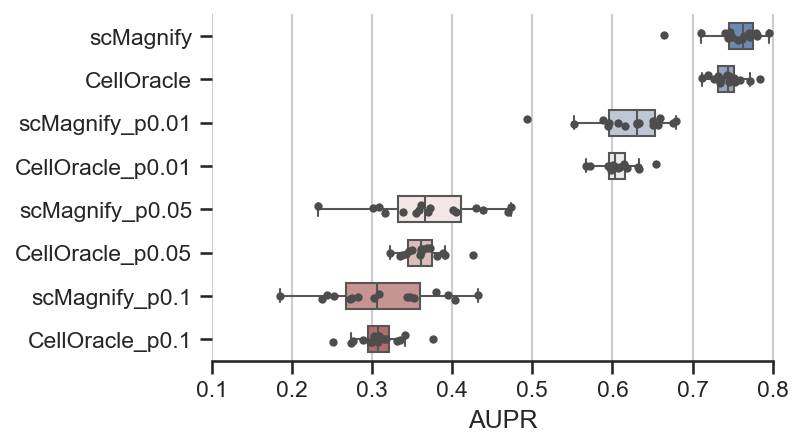

In [17]:
sns.set_theme(style="ticks")

# Initialize the figure with a logarithmic x axis
fig, ax = plt.subplots(figsize=(5, 3))
# ax.set_xscale("log")

# Plot the orbital period with horizontal boxes
sns.boxplot(
    filtered_metrics_grn1139, x="AUPR", y="Algorithm", hue="Algorithm",
    order=order, hue_order=order,
    width=.6, palette="vlag", 
    flierprops=dict(
        marker='D',        
        markerfacecolor='red',
        markeredgecolor='black',
        markersize=0,
        linestyle='none'
    )
)

# Add in points to show each observation
sns.stripplot(filtered_metrics_grn1139, x="AUPR", y="Algorithm", size=4, color=".3", order=order)

# Tweak the visual presentation
ax.xaxis.grid(True)
ax.set(ylabel="")
ax.set_xticks([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8])

sns.despine(trim=True, left=True)

plt.savefig(os.path.join(fig_dir, "Fig2b-scMultiSim_grn1139_AUPR.pdf"), bbox_inches='tight', transparent=True)

2025-10-09 12:16:20 | [INFO] maxp pruned
2025-10-09 12:16:20 | [INFO] LTSH dropped
2025-10-09 12:16:20 | [INFO] cmap pruned
2025-10-09 12:16:20 | [INFO] kern pruned
2025-10-09 12:16:20 | [INFO] post pruned
2025-10-09 12:16:20 | [INFO] PCLT dropped
2025-10-09 12:16:20 | [INFO] DSIG dropped
2025-10-09 12:16:20 | [INFO] glyf pruned
2025-10-09 12:16:20 | [INFO] Added gid0 to subset
2025-10-09 12:16:20 | [INFO] Added first four glyphs to subset
2025-10-09 12:16:20 | [INFO] Closing glyph list over 'glyf': 32 glyphs before
2025-10-09 12:16:20 | [INFO] Glyph names: ['.notdef', '.null', 'A', 'C', 'M', 'O', 'R', 'U', 'a', 'c', 'e', 'eight', 'f', 'five', 'four', 'g', 'i', 'l', 'n', 'nine', 'nonmarkingreturn', 'one', 'p', 'period', 'r', 's', 'seven', 'six', 'space', 'underscore', 'y', 'zero']
2025-10-09 12:16:20 | [INFO] Glyph IDs:   [0, 1, 2, 3, 17, 19, 20, 23, 24, 25, 26, 27, 28, 36, 38, 48, 50, 53, 56, 66, 68, 70, 72, 73, 74, 76, 79, 81, 83, 85, 86, 92]
2025-10-09 12:16:20 | [INFO] Closed glyph

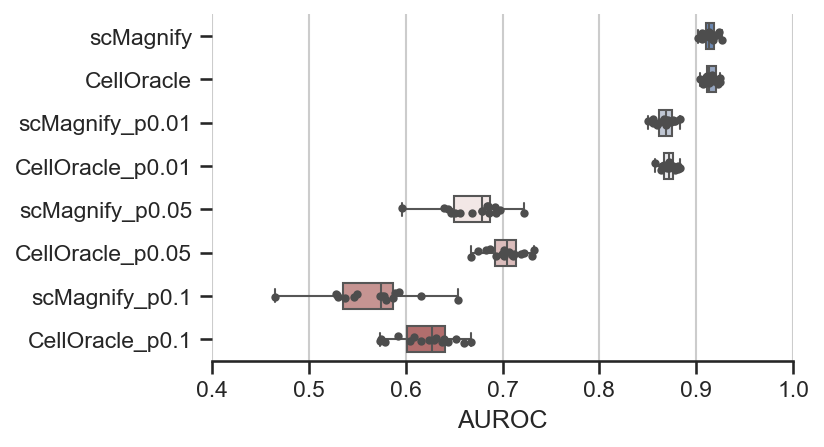

In [18]:
sns.set_theme(style="ticks")

# Initialize the figure with a logarithmic x axis
f, ax = plt.subplots(figsize=(5, 3))
# ax.set_xscale("log")

# Plot the orbital period with horizontal boxes
sns.boxplot(
    filtered_metrics_grn1139, x="AUROC", y="Algorithm", hue="Algorithm",
    order=order, hue_order=order,
    width=.6, palette="vlag", 
    flierprops=dict(
        marker='D',      
        markerfacecolor='red',
        markeredgecolor='black',
        markersize=0,
        linestyle='none'
    )
)

# Add in points to show each observation
sns.stripplot(filtered_metrics_grn1139, x="AUROC", y="Algorithm", size=4, color=".3", order=order)

# Tweak the visual presentation
ax.xaxis.grid(True)
ax.set(ylabel="")
ax.set_xticks([0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])

sns.despine(trim=True, left=True)

plt.savefig(os.path.join(fig_dir, "SupFig2a-scMultiSim_grn1139_AUROC.pdf"), bbox_inches='tight', transparent=True)

2025-10-16 20:43:19 | [INFO] maxp pruned
2025-10-16 20:43:19 | [INFO] LTSH dropped
2025-10-16 20:43:19 | [INFO] cmap pruned
2025-10-16 20:43:19 | [INFO] kern pruned
2025-10-16 20:43:19 | [INFO] post pruned
2025-10-16 20:43:19 | [INFO] PCLT dropped
2025-10-16 20:43:19 | [INFO] DSIG dropped
2025-10-16 20:43:19 | [INFO] glyf pruned
2025-10-16 20:43:19 | [INFO] Added gid0 to subset
2025-10-16 20:43:19 | [INFO] Added first four glyphs to subset
2025-10-16 20:43:19 | [INFO] Closing glyph list over 'glyf': 36 glyphs before
2025-10-16 20:43:19 | [INFO] Glyph names: ['.notdef', '.null', 'C', 'F', 'M', 'O', 'S', 'a', 'c', 'e', 'eight', 'f', 'five', 'four', 'g', 'i', 'k', 'l', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'period', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'underscore', 'y', 'zero']
2025-10-16 20:43:19 | [INFO] Glyph IDs:   [0, 1, 2, 3, 11, 12, 17, 19, 20, 22, 23, 24, 25, 26, 27, 38, 41, 48, 50, 54, 66, 68, 70, 72, 73, 74, 76, 78, 79, 81, 82, 83, 85,

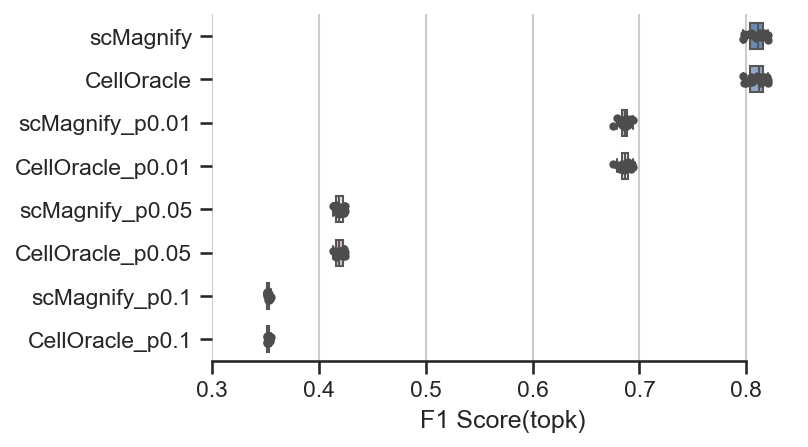

In [18]:
sns.set_theme(style="ticks")

# Initialize the figure with a logarithmic x axis
f, ax = plt.subplots(figsize=(5, 3))
# ax.set_xscale("log")

# Plot the orbital period with horizontal boxes
sns.boxplot(
    filtered_metrics_grn1139, x="F1 Score(topk)", y="Algorithm", hue="Algorithm",
    order=order, hue_order=order,
    width=.6, palette="vlag", 
    flierprops=dict(
        marker='D',      
        markerfacecolor='red',
        markeredgecolor='black',
        markersize=0,
        linestyle='none'
    )
)

# Add in points to show each observation
sns.stripplot(filtered_metrics_grn1139, x="F1 Score(topk)", y="Algorithm", size=4, color=".3", order=order)

# Tweak the visual presentation
ax.xaxis.grid(True)
ax.set(ylabel="")
ax.set_xticks([0.3, 0.4, 0.5, 0.6, 0.7, 0.8])

sns.despine(trim=True, left=True)

plt.savefig(os.path.join(fig_dir, "SupFig2a-scMultiSim_grn1139_F1.pdf"), bbox_inches='tight', transparent=True)

2025-10-16 20:47:13 | [INFO] maxp pruned
2025-10-16 20:47:13 | [INFO] LTSH dropped
2025-10-16 20:47:13 | [INFO] cmap pruned
2025-10-16 20:47:13 | [INFO] kern pruned
2025-10-16 20:47:13 | [INFO] post pruned
2025-10-16 20:47:13 | [INFO] PCLT dropped
2025-10-16 20:47:13 | [INFO] DSIG dropped
2025-10-16 20:47:13 | [INFO] glyf pruned
2025-10-16 20:47:13 | [INFO] Added gid0 to subset
2025-10-16 20:47:13 | [INFO] Added first four glyphs to subset
2025-10-16 20:47:13 | [INFO] Closing glyph list over 'glyf': 40 glyphs before
2025-10-16 20:47:13 | [INFO] Glyph names: ['.notdef', '.null', 'A', 'C', 'F', 'M', 'O', 'P', 'R', 'S', 'U', 'a', 'c', 'e', 'eight', 'f', 'five', 'four', 'g', 'i', 'k', 'l', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'period', 'r', 's', 'seven', 'six', 'space', 't', 'underscore', 'y', 'zero']
2025-10-16 20:47:13 | [INFO] Glyph IDs:   [0, 1, 2, 3, 11, 12, 17, 19, 20, 23, 24, 25, 26, 27, 28, 36, 38, 41, 48, 50, 51, 53, 54, 56, 66, 68, 70, 72, 

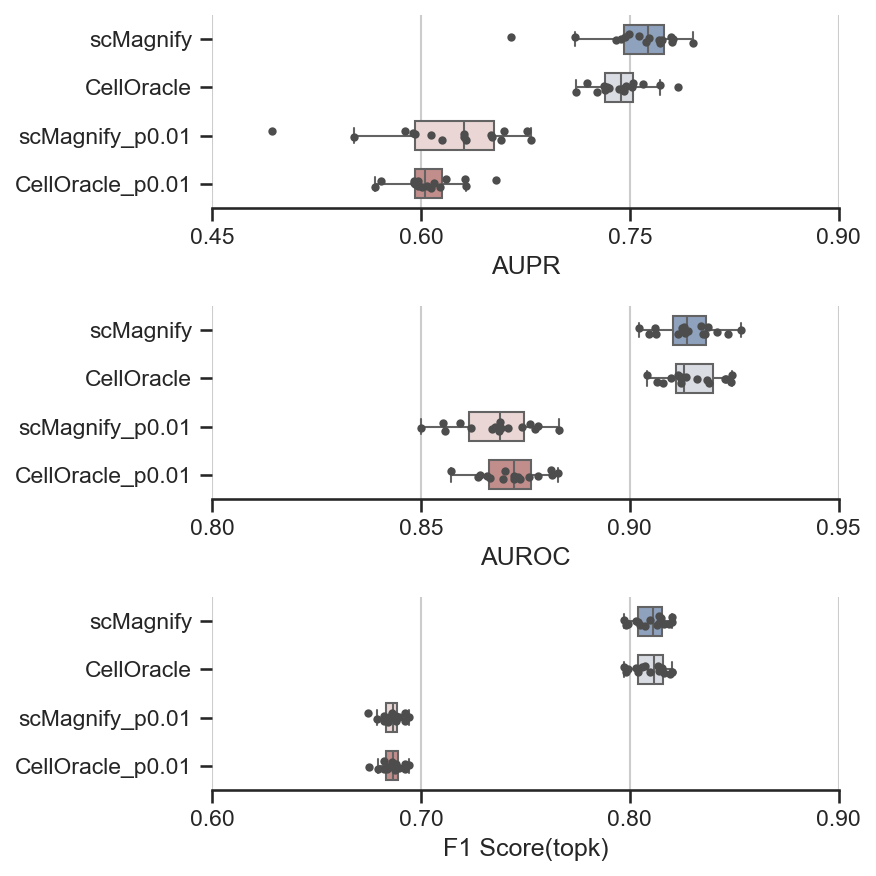

In [24]:
from statannotations.Annotator import Annotator

sns.set_theme(style="ticks")
order = ["scMagnify", "CellOracle",
         "scMagnify_p0.01", "CellOracle_p0.01"]
# Initialize the figure with a logarithmic x axis
fig, axes = plt.subplots(3, 1, figsize=(6, 6))
# ax.set_xscale("log")
ax_aupr = axes[0]
ax_auroc = axes[1]
ax_f1 = axes[2]

pairs = [
    ("scMagnify", "CellOracle"),
    ("scMagnify_p0.01", "CellOracle_p0.01"),
]

# Plot the orbital period with horizontal boxes
ax_aupr = sns.boxplot(
    filtered_metrics_grn1139, x="AUPR", y="Algorithm", hue="Algorithm",
    order=order, hue_order=order,
    width=.6, palette="vlag", 
    flierprops=dict(
        marker='D',      
        markerfacecolor='red',
        markeredgecolor='black',
        markersize=0,
        linestyle='none'
    ),
    ax=ax_aupr,
)

# Add in points to show each observation
sns.stripplot(filtered_metrics_grn1139, x="AUPR", y="Algorithm", size=4, color=".3", order=order, ax=ax_aupr)

ax_aupr.xaxis.grid(True)
ax_aupr.set(ylabel="")
ticks = [0.45, 0.60, 0.75, 0.90]
ax_aupr.set_xticks(ticks)
labels = [f'{tick:.2f}' for tick in ticks]
ax_aupr.set_xticklabels(labels)

# annotator = Annotator(ax_aupr, pairs, data=filtered_metrics_grn1139, x="AUPR", y="Algorithm", order=order)
# annotator.configure(test='Mann-Whitney', text_format='star', loc='outside')
# annotator.apply_and_annotate()

# Plot the orbital period with horizontal boxes
sns.boxplot(
    filtered_metrics_grn1139, x="AUROC", y="Algorithm", hue="Algorithm",
    order=order, hue_order=order,
    width=.6, palette="vlag", 
    flierprops=dict(
        marker='D',      
        markerfacecolor='red',
        markeredgecolor='black',
        markersize=0,
        linestyle='none'
    ),
    ax=ax_auroc
)

# Add in points to show each observation
sns.stripplot(filtered_metrics_grn1139, x="AUROC", y="Algorithm", size=4, color=".3", order=order, ax=ax_auroc)

ax_auroc.xaxis.grid(True)
ax_auroc.set(ylabel="")
ticks = [0.80, 0.85, 0.90, 0.95]
ax_auroc.set_xticks(ticks)
labels = [f'{tick:.2f}' for tick in ticks]
ax_auroc.set_xticklabels(labels)


sns.boxplot(
    filtered_metrics_grn1139, x="F1 Score(topk)", y="Algorithm", hue="Algorithm",
    order=order, hue_order=order,
    width=.6, palette="vlag", 
    flierprops=dict(
        marker='D',      
        markerfacecolor='red',
        markeredgecolor='black',
        markersize=0,
        linestyle='none'
    ),
    ax=ax_f1
)

# Add in points to show each observation
sns.stripplot(filtered_metrics_grn1139, x="F1 Score(topk)", y="Algorithm", size=4, color=".3", order=order, ax=ax_f1)
ax_f1.xaxis.grid(True)
ax_f1.set(ylabel="")
ticks = [0.60, 0.70, 0.80, 0.90]
ax_f1.set_xticks(ticks)
labels = [f'{tick:.2f}' for tick in ticks]
ax_f1.set_xticklabels(labels)


# annotator = Annotator(ax_auroc, pairs, data=filtered_metrics_grn1139, x="AUROC", y="Algorithm")
# annotator.configure(test='Mann-Whitney', text_format='star', loc='outside')
# annotator.apply_and_annotate()

sns.despine(trim=True, left=True)

plt.tight_layout()

plt.savefig(os.path.join(fig_dir, "Fig2b-scMultiSim_grn1139_AURR_AUROC_F1.pdf"), bbox_inches='tight', transparent=True)

2025-10-16 20:47:02 | [INFO] maxp pruned
2025-10-16 20:47:02 | [INFO] LTSH dropped
2025-10-16 20:47:02 | [INFO] cmap pruned
2025-10-16 20:47:02 | [INFO] kern pruned
2025-10-16 20:47:02 | [INFO] post pruned
2025-10-16 20:47:02 | [INFO] PCLT dropped
2025-10-16 20:47:02 | [INFO] DSIG dropped
2025-10-16 20:47:02 | [INFO] glyf pruned
2025-10-16 20:47:02 | [INFO] Added gid0 to subset
2025-10-16 20:47:02 | [INFO] Added first four glyphs to subset
2025-10-16 20:47:02 | [INFO] Closing glyph list over 'glyf': 33 glyphs before
2025-10-16 20:47:02 | [INFO] Glyph names: ['.notdef', '.null', 'A', 'C', 'M', 'O', 'P', 'R', 'U', 'a', 'c', 'e', 'eight', 'f', 'five', 'four', 'g', 'i', 'l', 'n', 'nine', 'nonmarkingreturn', 'one', 'p', 'period', 'r', 's', 'seven', 'six', 'space', 'underscore', 'y', 'zero']
2025-10-16 20:47:02 | [INFO] Glyph IDs:   [0, 1, 2, 3, 17, 19, 20, 23, 24, 25, 26, 27, 28, 36, 38, 48, 50, 51, 53, 56, 66, 68, 70, 72, 73, 74, 76, 79, 81, 83, 85, 86, 92]
2025-10-16 20:47:02 | [INFO] Clo

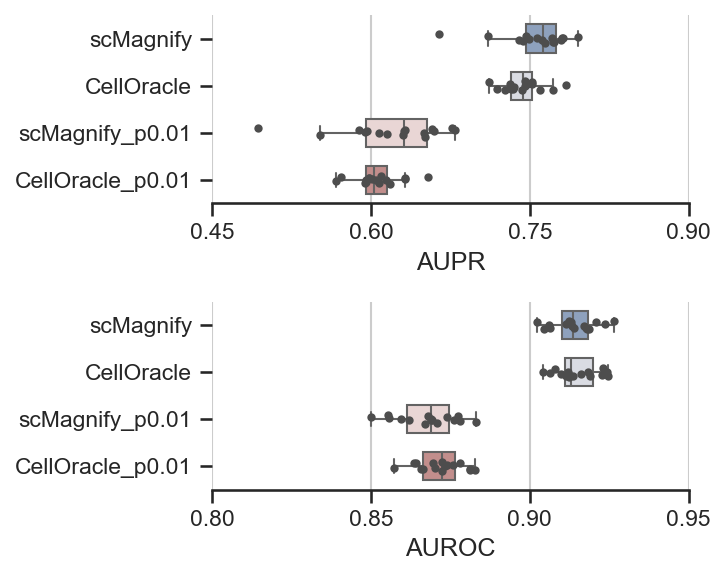

In [23]:
from statannotations.Annotator import Annotator

sns.set_theme(style="ticks")
order = ["scMagnify", "CellOracle",
         "scMagnify_p0.01", "CellOracle_p0.01"]
# Initialize the figure with a logarithmic x axis
fig, axes = plt.subplots(2, 1, figsize=(5, 4))
# ax.set_xscale("log")
ax_aupr = axes[0]
ax_auroc = axes[1]

pairs = [
    ("scMagnify", "CellOracle"),
    ("scMagnify_p0.01", "CellOracle_p0.01"),
]

# Plot the orbital period with horizontal boxes
ax_aupr = sns.boxplot(
    filtered_metrics_grn1139, x="AUPR", y="Algorithm", hue="Algorithm",
    order=order, hue_order=order,
    width=.6, palette="vlag", 
    flierprops=dict(
        marker='D',      
        markerfacecolor='red',
        markeredgecolor='black',
        markersize=0,
        linestyle='none'
    ),
    ax=ax_aupr,
)

# Add in points to show each observation
sns.stripplot(filtered_metrics_grn1139, x="AUPR", y="Algorithm", size=4, color=".3", order=order, ax=ax_aupr)

ax_aupr.xaxis.grid(True)
ax_aupr.set(ylabel="")
ticks = [0.45, 0.60, 0.75, 0.90]
ax_aupr.set_xticks(ticks)
labels = [f'{tick:.2f}' for tick in ticks]
ax_aupr.set_xticklabels(labels)

# annotator = Annotator(ax_aupr, pairs, data=filtered_metrics_grn1139, x="AUPR", y="Algorithm", order=order)
# annotator.configure(test='Mann-Whitney', text_format='star', loc='outside')
# annotator.apply_and_annotate()

# Plot the orbital period with horizontal boxes
sns.boxplot(
    filtered_metrics_grn1139, x="AUROC", y="Algorithm", hue="Algorithm",
    order=order, hue_order=order,
    width=.6, palette="vlag", 
    flierprops=dict(
        marker='D',      
        markerfacecolor='red',
        markeredgecolor='black',
        markersize=0,
        linestyle='none'
    ),
    ax=ax_auroc
)

# Add in points to show each observation
sns.stripplot(filtered_metrics_grn1139, x="AUROC", y="Algorithm", size=4, color=".3", order=order, ax=ax_auroc)

ax_auroc.xaxis.grid(True)
ax_auroc.set(ylabel="")
ticks = [0.80, 0.85, 0.90, 0.95]
ax_auroc.set_xticks(ticks)
labels = [f'{tick:.2f}' for tick in ticks]
ax_auroc.set_xticklabels(labels)




# annotator = Annotator(ax_auroc, pairs, data=filtered_metrics_grn1139, x="AUROC", y="Algorithm")
# annotator.configure(test='Mann-Whitney', text_format='star', loc='outside')
# annotator.apply_and_annotate()

sns.despine(trim=True, left=True)

plt.tight_layout()

plt.savefig(os.path.join(fig_dir, "Fig2b-scMultiSim_grn1139_AURR_AUROC.pdf"), bbox_inches='tight', transparent=True)

In [31]:
metric_median = filtered_metrics_grn1139.groupby("Algorithm")[["AUPR", "AUROC", "F1 Score(topk)"]].median()

In [37]:
metric_mean = filtered_metrics_grn1139.groupby("Algorithm")[["AUPR", "AUROC", "F1 Score(topk)"]].mean()

In [36]:
(metric_median.loc["scMagnify", "AUPR"] - metric_median.loc["CellOracle", "AUPR"]) / metric_median.loc["CellOracle", "AUPR"] * 100

2.5121910387026776

In [39]:
(metric_median.loc["scMagnify", "F1 Score(topk)"] - metric_median.loc["CellOracle", "F1 Score(topk)"]) / metric_median.loc["CellOracle", "F1 Score(topk)"] * 100

-0.04733259163146585

In [38]:
(metric_mean.loc["scMagnify", "AUPR"] - metric_mean.loc["CellOracle", "AUPR"]) / metric_mean.loc["CellOracle", "AUPR"] * 100

1.661711525179156

## Save the data

In [21]:
output_xlsx = os.path.join(data_dir, "SourceDataFig2b.xlsx")

with pd.ExcelWriter(output_xlsx, engine='xlsxwriter') as writer:
    filtered_metrics_grn1139.to_excel(writer, sheet_name='Fig2b', index=False)